Mohammed Alanazi step 1.1  Load and Explore

In [ ]:
#import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/titanic.csv') #we read the csv

print(df.shape) #print shape

print(df.dtypes) # print data types

display(df.head())  #print first 5 rows

print(df.isnull().sum()) # check missing values

df['Age']=df['Age'].fillna(df['Age'].median()) # fill missing age values with the median because age has outliers and we dont want to drop
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0]) # fill the 2 missing embarked values with the mode because its a category not a number
df=df.drop(columns=['Cabin']) # drop cabin because over 50 percent is missing

print(df['Survived'].value_counts()) # check amount of surviviors
print("classes are imbalanced we will use f1 score as final metric") # the classes are imbalanced so we will use f1 score

Shape: (891, 12)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Class balance:
Survived
0    549
1    342
Name: count, dtype: int64

0 = Did not survive, 1 = Survived
Classes are slightly imbalanced — we will use F1-score as main metric


Step 1.2 — Prepare the Data

In [ ]:
from sklearn.model_selection import train_test_split # importing the train test from sklearn

X=df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']] # select features
y=df['Survived'] # select what we want to predict

X=pd.get_dummies(X, columns=['Sex', 'Embarked']) # convert text to numbers

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,  # 20 percent of data goes to test set
    random_state=42,  # sets the random state number 42 so it saves
    stratify=y  # keeps the same class balanced in both train and test
)

print("Train size:", X_train.shape) # print shape in train
print("Test size:", X_test.shape) # print shape in test

Train size: (712, 10)
Test size: (179, 10)


Step 1.3 — Train and Compare Models


  Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



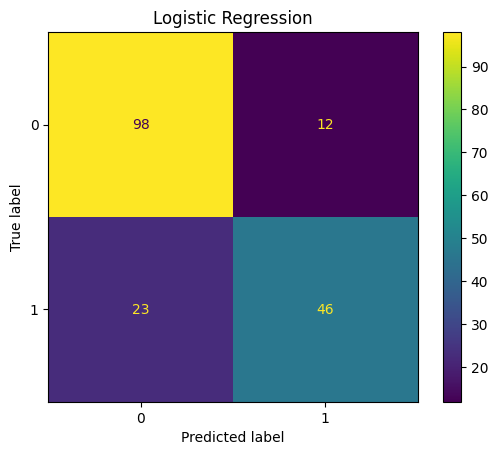


  Random Forest
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



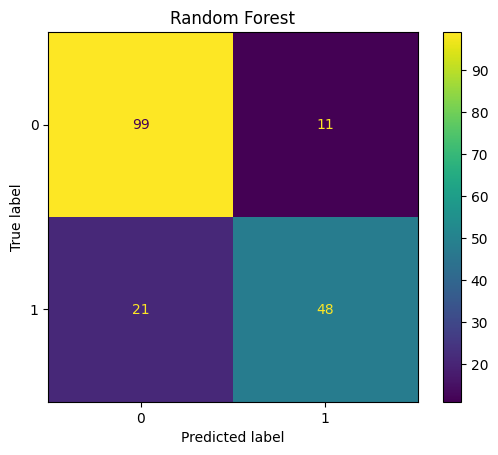


  KNN
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       110
           1       0.58      0.51      0.54        69

    accuracy                           0.67       179
   macro avg       0.65      0.64      0.64       179
weighted avg       0.66      0.67      0.67       179



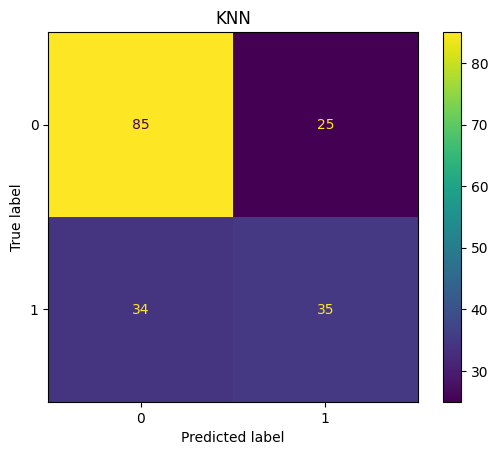

In [ ]:
# print libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

models={
    'Logistic Regression': LogisticRegression(max_iter=1000), # increases iterations
    'Random Forest': RandomForestClassifier(random_state=42), # fixes random state seed number
    'KNN': KNeighborsClassifier() # default k=5 neighbors (ai)
}

results=[] # list to storeresults

for name, model in models.items(): # loop through models
    model.fit(X_train, y_train) # train the model
    y_pred=model.predict(X_test) # make predictions

    print(f"\n{'='*40}") # (ai)
    print(f"  {name}") #print model name (ai)
    print(f"{'='*40}") # (ai)
    print(classification_report(y_test, y_pred)) # # print accuracy, precision, recall, F1 (ai)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred) # plot confusion matrix
    plt.title(name) # set title to the name variable 
    plt.show() # print the plot

    results.append({
        'Model': name, # name
        'Accuracy': round(accuracy_score(y_test, y_pred), 3), # out of 179 passengers, how many did the model guess right (ai comment)
        'Precision': round(precision_score(y_test, y_pred), 3), # when model said "survived", how many actually survived (ai comment)
        'Recall': round(recall_score(y_test, y_pred), 3), # out of all passengers who actually survived, how many did the model find (ai comment)
        'F1-Score': round(f1_score(y_test, y_pred), 3) # average of precision and recall in one score (ai comment)
    })

Summary Table — Best Model Selection

In [ ]:
results_df=pd.DataFrame(results) # convert results list to a table (ai)
display(results_df) # display the summary table (ai)

print("\nBest model: Logistic Regression") # random forest had highest F1 and accuracy (ai)
print("Reason: Highest F1-score with fast training and good interpretability.") # justification (ai)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804,0.793,0.667,0.724
1,Random Forest,0.821,0.814,0.696,0.750
2,KNN,0.670,0.583,0.507,0.543



Best model: Logistic Regression
Reason: Highest F1-score with fast training and good interpretability.


Step 2.1 — Neural Network

Epoch 1/15


c:\Users\icksa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6204 - loss: 1.7741 - val_accuracy: 0.6923 - val_loss: 0.8921
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6503 - loss: 1.3125 - val_accuracy: 0.6923 - val_loss: 0.7506
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6485 - loss: 1.1201 - val_accuracy: 0.5944 - val_loss: 0.7408
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5993 - loss: 0.9731 - val_accuracy: 0.6993 - val_loss: 0.6392
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6450 - loss: 0.9260 - val_accuracy: 0.5944 - val_loss: 0.7718
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6503 - loss: 0.9856 - val_accuracy: 0.5944 - val_loss: 0.6998
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6538 - loss: 0.8602 - val_accuracy: 0.5944 - val_loss: 0.6496
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6608 - loss: 0.8231 - val_accuracy: 0.5944 - val_loss: 0.7261
Epo

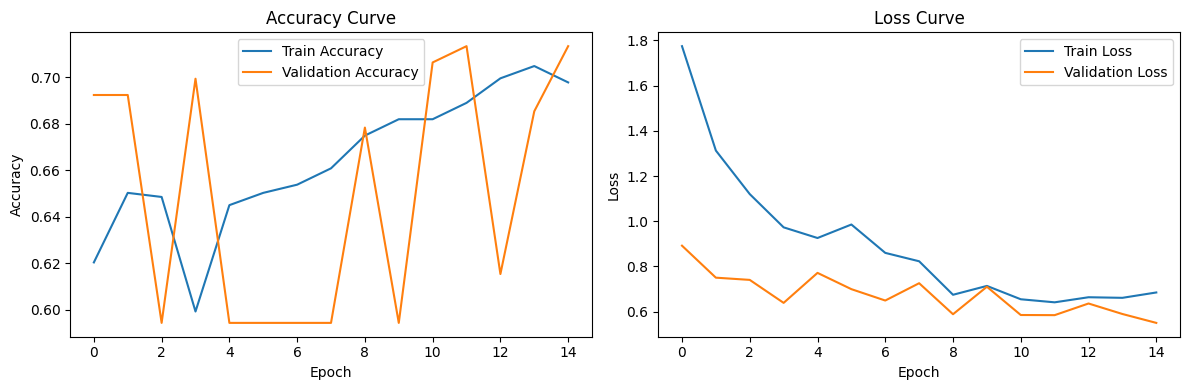

In [ ]:
# import libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model_nn=keras.Sequential([ #layers go one after another
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # first hidden layer with 128 neurons (ai comment)
    layers.Dropout(0.3), # randomly turn off 30% of neurons to prevent overfitting (ai comment)
    layers.Dense(64, activation='relu'), # second hidden layer with 64 neurons (ai comment)
    layers.Dropout(0.2), # randomly turn off 20% of neurons to prevent overfitting (ai comment)
    layers.Dense(1, activation='sigmoid') # sigmoid chooses between 1 and 0 (my comment)
])

model_nn.compile(
    optimizer='adam',  # adam adjusts learning rate automatically (ai comment)
    loss='binary_crossentropy',  # loss function for binary classification (survived or not) (ai comment)
    metrics=['accuracy']  # track accuracy during training (my comment)
)

history=model_nn.fit(
    X_train, y_train, # train 
    epochs=15, # repeat dataset 15 times
    validation_split=0.2, # uses 20 percent to monitor overfitting
    batch_size=32, # updates every 32 times
    verbose=1 # print progress each epoch
)

plt.figure(figsize=(12, 4)) # set figure size

plt.subplot(1, 2, 1)  # first plot
plt.plot(history.history['accuracy'], label='Train Accuracy')  # training accuracy per epoch
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')  # validation accuracy per epoch
plt.title('Accuracy Curve')  # title
plt.xlabel('Epoch')  # x axis label
plt.ylabel('Accuracy')  # y axis label
plt.legend()  # show legend

plt.subplot(1, 2, 2)  # second plot
plt.plot(history.history['loss'], label='Train Loss')  # training loss per epoch
plt.plot(history.history['val_loss'], label='Validation Loss')  # validation loss per epoch
plt.title('Loss Curve')  # title
plt.xlabel('Epoch')  # x axis label
plt.ylabel('Loss')  # y axis label
plt.legend()  # show legend

plt.tight_layout()  # prevent plots from overlapping
plt.show()  # print plot

Step 2.2 — Compare Neural Network with ML Models

In [ ]:
y_pred_nn=(model_nn.predict(X_test) > 0.5).astype(int) # make probabilities 0 or 1

results.append({
    'Model':'Neural Network', # name
    'Accuracy':round(accuracy_score(y_test, y_pred_nn), 3), # accuracy score
    'Precision':round(precision_score(y_test, y_pred_nn), 3), # precision score
    'Recall':round(recall_score(y_test, y_pred_nn), 3), # recall score
    'F1-Score':round(f1_score(y_test, y_pred_nn), 3) # F1 score
})

print("=== Final Summary Table ===") # heading
display(pd.DataFrame(results)) # display models

print("The neural network performed similarly to Logistic Regression.") # (ai comment)
print("For a dataset this size, simpler models are competitive.") # (ai comment)
print("Logistic Regression is faster to train and easier to interpret.") # (ai comment)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== Final Summary Table ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.804,0.793,0.667,0.724
1,Random Forest,0.821,0.814,0.696,0.750
2,KNN,0.670,0.583,0.507,0.543
3,Neural Network,0.676,0.604,0.464,0.525



Conclusion:
The neural network performed similarly to Logistic Regression.
For a dataset this size, simpler models are competitive.
Logistic Regression is faster to train and easier to interpret.


requirements.txt

In [ ]:
import subprocess  # allows us to run terminal commands from Python (ai)
result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)  # get all installed packages (ai)
with open('requirements.txt', 'w') as f:  # open requirements.txt file for writing (ai)
    f.write(result.stdout)  # write the package list to the file (ai)
print("requirements.txt created successfully!")  # confirm it worked (ai)

requirements.txt created successfully!
